### 4. 신경망 학습
- **📍학습 = 훈련 데이터로부터 가중치 매개변수의 최적값을 자동으로 획득하는 것**
- 💥 신경망이 학습 할 수 있도록 해주는 지표 = **손실 함수**
- **학습의 목표 = 손실함수의 결괏값을 가장 작게 만드는 가중치 매개변수를 찾는 것**
- 손실함수의 값을 가급적 작게 만드는 기법 = 핳ㅁ수의 기울기를 활용하는 경사법을 배울 것

---

###### 복습 : 퍼셉트론 --(활성화 함수 사용)--> 신경망 --(손실함수)--> 신경망 학습

#### 4-1. 데이터에서 학습한다!
- 신경망의 특징 = 데이터를 통해 학습할 수 있다는 것 = 가중치 매개변수의 값을 데이터를 보고 자동으로 결정함 

##### 4-1-1. 데이터 주도 학습
- 방법 1. 이미지 --(사람이 생각한 알고리즘)--> 결과
- 방법 2. 이미지 --(사람이 생각한 특징 추출 : HOG, SIFT, SURF)--(머신러닝으로 특징 학습: SVM,KNN)--> 결과
- 방법 3. 이미지 --(신경망(딥러닝))--> 결과

💥 **[방법 2]에서는 이미지의 특징을 사람이 설계했지만, 신경망은 이미지에 포함된 중요 특징까지도 기계가 스스로 학습**

##### 4-1-2. 훈련 데이터와 시험 데이터
- 훈련 데이터와 시험 데이터로 나눠서 학습과 실험을 수행하는 것이 일반적
- 훈련 데이터 : 학습하면서 최적의 매개변수를 찾기
- 시험 데이터 : 앞서 훈련한 모델의 실력을 평가 = 범용 능력을 평가하기 위함

💥 **한 데이터셋에만 지나치게 최적화된 상태 = 과대적합(오버피팅)**

### 4-2. 손실 함수
신경망 학습에서는 현재의 상태를 '하나의 지표'로 표현하고, 이 지표를 가장 좋게 만들어주는 가중치 매개변수의 값을 탐색하는 것이 목표

- 📍 **위와 같은 '최적의 지표'를 찾기 위해서 사용하는 것이 손실함수**
- 대표적으로 많이 사용하는 손실 함수 = 오차제곱합 & 교차 엔트로피 오차

💥 **오차가 작으면 작을수록 정답에 가까운 것(잘 학습된 것)**

#### 4-2-1. 오차제곱합(SSE)
$$SSE = \frac{1}{2}\sum_{k=1}^{K} (y_k - t_k)^2$$

- $y_k$ = 신경망이 예측한 값
- $t_k$ = 정답 레이블
- k = 데이터 차원의 수

In [3]:
import numpy as np
def sum_squares_error(y, t):
    return 0.5 * np.sum((y-t)**2)

In [4]:
 #정답 레이블. 답은 2라고 명시한 것
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]

#신경망의 예측값(2일 확률이 가장 높다고 예측)
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
print(sum_squares_error(np.array(y), np.array(t)))

#신경망의 예측값(7일 확률이 가장 높다고 예측) -> 잘못된 예측
y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]
print(sum_squares_error(np.array(y), np.array(t)))

0.09750000000000003
0.5975


#### 4-2-2. 교차 엔트로피 오차(CEE)
$$CEE = -\sum_{k=1}^{K} t_k \log(y_k)$$
- log는 밑이 e인 자연로그
- $y_k$ = 신경망의 출력(신경망의 예측값)
- $t_k$ = 정답에 해당하는 인덱스의 원소만 1이고 나머지는 0 -> 실질적으로 정답일 때의 추정의 자연로그를 계산

In [ ]:
def cross_entropy_error(y, t):
    delta = 1e-7 #log에 0을 입력하면 -inf가 되는데, 이를 방지하기 위함
    return -np.sum(t * np.log(y + delta))

In [6]:
#정답 레이블. 답은 2라고 명시한 것
t = [0, 0, 1, 0, 0, 0, 0, 0, 0, 0]

#신경망의 예측값(2일 확률이 가장 높다고 예측)
y = [0.1, 0.05, 0.6, 0.0, 0.05, 0.1, 0.0, 0.1, 0.0, 0.0]
print(cross_entropy_error(np.array(y), np.array(t)))

#신경망의 예측값(7일 확률이 가장 높다고 예측) -> 잘못된 예측
y = [0.1, 0.05, 0.1, 0.0, 0.05, 0.1, 0.0, 0.6, 0.0, 0.0]
print(cross_entropy_error(np.array(y), np.array(t)))

0.510825457099338
2.302584092994546


#### 4-2-3. 미니 배치 학습
- 머신러닝에서의 학습 = 훈련 데이터를 통해 학습함 = 훈련 데이터에 대한 손실 함수의 값을 구하고 그 값을 최대한 줄여주는 매개변수를 찾는 것
- 즉, 모든 학습 데이터에 대한 손실함수값 계산이 필요함 -> 훈련 데이터가 100000개가 있다면 100000번의 손실함수 값들의 합을 지표로 삼는 것(아래 수식과 같이...)

$$CEE = -\frac{1}{N}\sum_{n=1}^{N}\sum_{k=1}^{K} t_{nk} \log(y_{nk})$$

위와 같이 전체 데이터 수(N)로 나눠주면, 평균 손실 함수를 구할 수 있음

💥 **하지만, MNIST 데이터셋의 훈련 데이터셋을 보면 60,000개가 있기 때문에 이 모든 훈련 데이터셋을 가지고 손실 함수 값을 구하는 것은 시간이 걸림**

##### ✅ 그래서, 훈련 데이터로부터 일부만 골라서 학습을 수행함. 여기서의 '일부' = '미니 배치'라고 함. 그리고 미니 배치를 활용한 학습을 '미니 배치 학습'이라고 함

In [3]:
import sys, os

current_dir = os.getcwd() if '__file__' not in locals() else os.path.dirname(__file__)
parent_dir = os.path.join(current_dir, '..')
sys.path.append(parent_dir)

import numpy as np
from dataset.mnist import load_mnist

(x_train, t_train),(x_test, t_test) = load_mnist(normalize= True, one_hot_label=True)

print(x_train.shape)
print(t_train.shape)

#무작위로 10장만 빼서 '미니 배치' 만들기
train_size = x_train.shape[0]
batch_size = 10
batch_mask = np.random.choice(train_size, batch_size) #train_size = 60,000이므로 0-60,000중에서 랜덤으로 10개를 뽑는 복원추출 진행
x_batch = x_train[batch_mask]
t_batch = t_train[batch_mask]

print(x_batch)
print(t_batch)

(60000, 784)
(60000, 10)
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
[[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]


#### 4-2-4. (배치용) 교차 엔트로피 오차 구현하기 

In [ ]:
#원-핫 인코딩으로 정답 레이블이 주어진 경우의 교차 엔트로피 오차 구현

def cross_entropy_error(y, t):
    #입력값(y)의 차원이 1차원으로 들어왔다는 건... 이미지 1장에 대한 예측값이 클래스 n개에 대한 확률값으로 묶어서 들어왔다는 뜻이고
    #배치 처리를 하기 위해선 batch_size = y.shape[0]을 해야하는데, 1차원에서는 이걸 못하기 때문에.. 인위적으로(?) 2차원으로 바꿔줘야함 (1, y.size)처럼
    if y.ndim == 1: 
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0]
    return -np.sum(t * np.log(y + 1e+7)) / batch_size

In [5]:
#숫자 레이블로 정답 레이블이 주어진 경우의 

def cross_entropy_error(y, t):
    #입력값(y)의 차원이 1차원으로 들어왔다는 건... 이미지 1장에 대한 예측값이 클래스 n(10)개에 대한 확률값으로 묶어서 들어왔다는 뜻이고
    #배치 처리를 하기 위해선 batch_size = y.shape[0]을 해야하는데, 1차원에서는 이걸 못하기 때문에.. 인위적으로(?) 2차원으로 바꿔줘야함 (1, y.size)처럼
    if y.ndim == 1: 
        t = t.reshape(1, t.size)
        y = y.reshape(1, y.size)

    batch_size = y.shape[0]
    return -np.sum(np.log(y[np.arange(batch_size), t] + 1e+7)) / batch_size

#### 4-2-5. 왜 손실 함수를 설정하는가?
왜 보다 정확한 매개변수 가중치를 찾아내기 위하여 **'정확도'를 높히는 방향이 아니라 우회적인 방법인 '손실 함수'의 값을 줄이는 걸 사용할까???**

답은, 📍 **"미분"** 이다

신경망 학습에서 최적의 매개변수를 탐색할 때, 손실함수의 값을 가능한 작게하는 매개변수 값을 찾는다 
➡️ 이 때, 매개변수의 미분(기울기)를 계산하고, 그 미분 값을 단서로 매개변수의 값을 서서히 갱신하는 과정을 반복함

- 여기서 "가중치 매개변수의 손실 함수의 미분"이란 '가중치 매개변수의 값을 아주 조금 변화시켰을 때, 손실함수가 어떻게 변하나?' 라는 의미임
    - 미분값이 음수면 그 가중치 매개변수를 양의 방향으로 변화시켜 손실 함수의 값을 줄일 수 있음
    - 미분값이 양수면 그 가중치 매개변수를 음의 방향으로 변화시켜 손실 함수의 값을 줄일 수 있음
    - 미분값이 0이면 매개변수를 어느 쪽으로 움직여도 손실 함수의 값은 줄어들지 않기에 갱신을 멈춤

    💥 **정확도를 지표로 삼으면, 미분값이 대부분의 장소에서 0이 돼서 매개변수를 갱신할 수 없다는 문제가 발생함**



### 4-3. 수치 미분
#### 4-3-1. 미분
- 함수의 미분 = x의 '작은 변화'가 함수 $f(x)$를 얼마나 변화시키느냐를 의미함
- 아래 코드로 구현한 수치 미분 함수는 2가지 문제점을 가지고 있음
    - 1.반올림 오차 : h에 가급적 작은 값을 대입하고 싶어서 1e-50(소숫점 아래 0이 50개)를 대입했는데, 이는 반올림하면 0.0이 됨
    - 2.근사로 구한 접선의 문제 : $f(x)$와 $f(x+h)$ 사이의 접선은 근사로 구한 접선이기에 문제가 됨. 우리는 이를 x를 중심으로 한 차분을 계산해야함(중심차분)

In [6]:
#나쁜 구현의 예
def numerical_diff(f, x):
    h = 1e-50
    return (f(x+h) - f(x)) / h

In [ ]:
#개선된 구현의 예
def numerical_diff(f, x):
    h = 1e-4 #h = 0.0001
    return (f(x+h) - f(x-h)) / (2*h) #중앙차분 이용

#### 4-3-2. 수치 미분의 예
x = 5일 때와 x = 10일 때 아래 수식을 미분해보자.

$y = 0.01x^2 + 0.1x $

In [8]:
def function_1(x):
    return 0.01*x**2 + 0.1*x

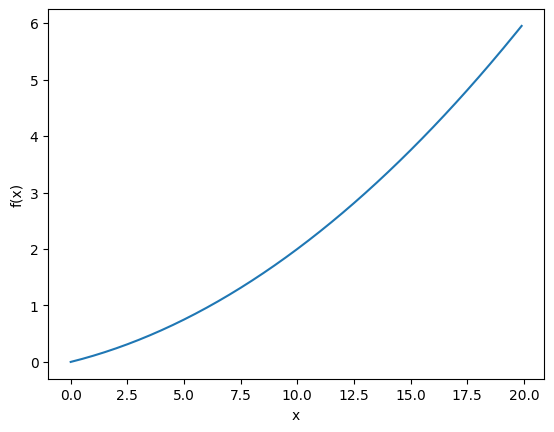

In [9]:
import numpy as np 
import matplotlib.pylab as plt

x = np.arange(0.0, 20.0, 0.1)
y = function_1(x)

plt.xlabel("x")
plt.ylabel("f(x)")
plt.plot(x,y)
plt.show()

In [10]:
print(numerical_diff(function_1, 5))
print(numerical_diff(function_1, 10))

0.1999999999990898
0.2999999999986347


#### 4-3-3. 편미분 
- 변수가 2개 이상인 식에 대한 미분

$x_0$ = 3 이고 $x_1$ = 4 일 때 아래 식에 대한 편미분을 진행해보자.

아래에서 편미분하는 방법은 동시에 진행하는 것이 아니라 각 변수에 대한 미분을 따로 진행하는 방식이다.

$f(x_0, x_1) = x_0^2 + x_1^2$

In [ ]:
#인수 x는 넘파이 배열이라고 가정
def function_2(x):
    return x[0]**2 + x[1]**2

In [ ]:
#x0에 대한 편미분
def fucntion_tmp1(x0):
    return x0*x0+4.0**2.0

print(numerical_diff(fucntion_tmp1, 3.0))

6.00000000000378


In [15]:
#x1에 대한 편미분
def fucntion_tmp2(x1):
    return 3.0**2.0+x1*x1

print(numerical_diff(fucntion_tmp2, 4.0))

7.999999999999119


### 4-4. 기울기
그렇다면 $x_0$과 $x_1$에 대한 편미분을 동시에 계산하고 싶다면 어떻게 할까?

- 양쪽의 편미분을 묶어서 아래와 같이 표현할 수 있음
$$\nabla f = \left(\frac{\partial f}{\partial x_0}, \frac{\partial f}{\partial x_1}\right)$$

그리고 여기서 📍 **기울기란 모든 변수의 편미분을 벡터로 정리한 것을 뜻함.**

In [ ]:
def numerical_gradient(f, x):
    h = 1e-4
    grad = np.zeros_like(x) #x와 형상이 같으면서 원소가 모두 0인 배열을 만듬

    for idx in range(x.size): 
        tmp_val = x[idx] #픽셀값을 하나하나 저장함

        #f(x+h) 계산
        x[idx] = tmp_val + h #픽셀값을 0.5 + 0.0001 = 0.5001로 바꾸고
        fxh1 = f(x)          #손실함수 계산

        #f(x-h) 계산
        x[idx] = tmp_val - h #픽셀값을 0.5 - 0.0001 = 0.5001로 바꾸고
        fxh2 = f(x)          #손실함수 계산

        grad[idx] = (fxh1 - fxh2)/(2*h) #기울기 계산
        x[idx] = tmp_val #값 복원

    return grad

print(numerical_gradient(function_2, np.array([3.0,4.0])))
print(numerical_gradient(function_2, np.array([0.0,2.0])))
print(numerical_gradient(function_2, np.array([3.0,0.0])))

[6. 8.]
[0. 4.]
[6. 0.]


##### 📍 **기울기가 가리키는 쪽은 각 장소에서 함수의 출력 값을 가장 크게 줄이는 방향임**

/Users/songga0ee/Desktop/HOME/deep_learning/dataset/gradient_2d.py:71: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


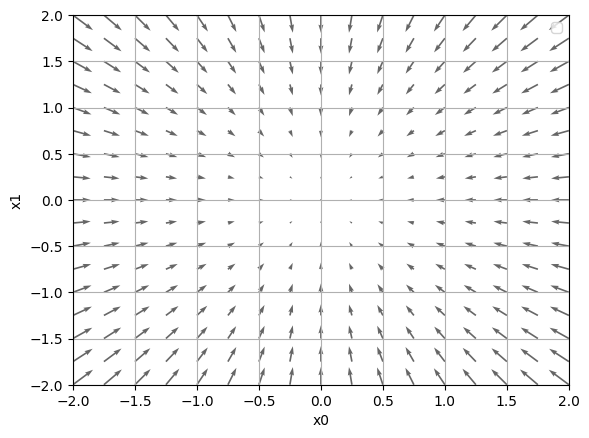

<Figure size 640x480 with 0 Axes>

In [20]:
%matplotlib inline
%run ../dataset/gradient_2d.py

#### 4-4-1. 경사법(경사 하강법)
- 💥 손실 함수가 최솟값이 될 때의 매개변수 값을 찾아야하는데, 매개변수 공간이 광대하여 어디가 최솟값이 되는 곳인지 찾기 어려움
- 이럴 때 기울기를 잘 이용해 함수의 최솟값을 찾으려는 기법이 **경사법(경사 하강법)**임

💥 기울어진 방향이 꼭 최솟값을 가리키는 것은 아니지만, 그 방향으로 가야 함수의 값을 줄일 수 있음
- 경사법 = 현 위치에서 일정 거리만큼 이동하고, 이동한 곳에서 기울기를 구하고, 또 나아가고를 반복

$$x_0 = x_0 - \eta \frac{\partial f}{\partial x_0}$$

$$x_1 = x_1 - \eta \frac{\partial f}{\partial x_1}$$

- $\eta$ = 학습률 = 한번에 갱신하는 양을 나타냄 = 매개변수의 값을 얼마나 갱신하느냐를 정하는 것

---
- $\eta$ = 학습률 = 한번에 갱신하는 양을 나타냄 = 매개변수의 값을 얼마나 갱신하느냐를 정하는 것 = 얼마나 이동할지?
- 기울기 = 어느 방향으로 이동할지 결정
- 마이너스(-) = 반대방향으로 전환하기 위함

In [ ]:
def gradient_descent(f, init_x, lr=0.01, step_num = 100):
    x = init_x

    for i in range(step_num):
        grad = numerical_gradient(f, x)
        #현재 위치(x)에서 기울기 방향으로 학습률만큼 이동해서 x를 갱신한다는 뜻
        x -= lr*grad
    
    return x

In [22]:
init_x = np.array([-3.0, 4.0])
a = gradient_descent(function_2, init_x = init_x, lr = 0.1, step_num = 100)
print(a)

[-6.11110793e-10  8.14814391e-10]


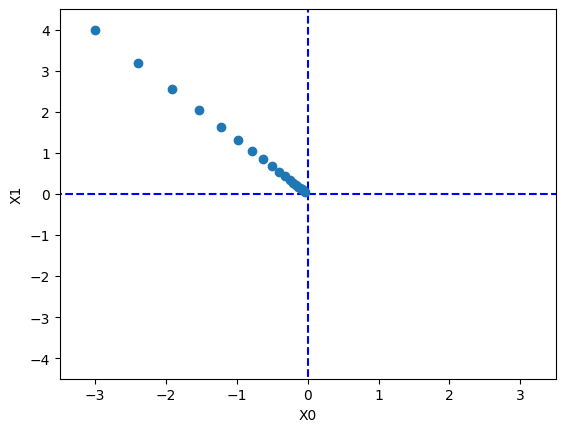

<Figure size 640x480 with 0 Axes>

In [24]:
%matplotlib inline
import sys
sys.path.append('../dataset')  # gradient_2d.py가 있는 폴더 경로

%run ../dataset/gradient_method.py  # 이 파일 경로도 수정!

In [25]:
#학습률이 너무 큰 예 -> 값이 발산해버림
init_x = np.array([-3.0, 4.0])
print(gradient_descent(function_2, init_x = init_x, lr = 10.0, step_num = 100))

#학습률이 너무 작은 예 -> 거의 갱신되지 않은채 종료됨(100step)
init_x = np.array([-3.0, 4.0])
print(gradient_descent(function_2, init_x = init_x, lr = 1e-10, step_num = 100))

(array([-2.58983747e+13, -1.29524862e+12]), array([[-3.00000000e+00,  4.00000000e+00],
       [ 5.70000000e+01, -7.60000000e+01],
       [-1.08300000e+03,  1.44400000e+03],
       [ 2.05770000e+04, -2.74360000e+04],
       [-3.90963008e+05,  5.21284002e+05],
       [ 7.42829664e+06, -9.90439654e+06],
       [-1.41137328e+08,  1.88183103e+08],
       [ 2.68126267e+09, -3.57501690e+09],
       [-5.09763373e+10,  6.79001831e+10],
       [ 9.45170863e+11, -1.29524862e+12],
       [-2.58983747e+13, -1.29524862e+12],
       [-2.58983747e+13, -1.29524862e+12],
       [-2.58983747e+13, -1.29524862e+12],
       [-2.58983747e+13, -1.29524862e+12],
       [-2.58983747e+13, -1.29524862e+12],
       [-2.58983747e+13, -1.29524862e+12],
       [-2.58983747e+13, -1.29524862e+12],
       [-2.58983747e+13, -1.29524862e+12],
       [-2.58983747e+13, -1.29524862e+12],
       [-2.58983747e+13, -1.29524862e+12],
       [-2.58983747e+13, -1.29524862e+12],
       [-2.58983747e+13, -1.29524862e+12],
       [-2

#### 4-4-2. 신경망에서의 기울기
예를들어, 형상이 2X3, 가중치가 W, 손실함수가 L인 신경망을 생각해보자.

이 경우 경사는 $$\frac{\partial L}{\partial W} = \begin{pmatrix} \frac{\partial L}{\partial w_{00}} & \frac{\partial L}{\partial w_{01}} & \frac{\partial L}{\partial w_{02}} \\ \frac{\partial L}{\partial w_{10}} & \frac{\partial L}{\partial w_{11}} & \frac{\partial L}{\partial w_{12}} \end{pmatrix}$$ 다음과 같이 나타낼 수 있다.

즉, $$\frac{\partial L}{\partial w_{11}} = \frac{L(w_{11} + h) - L(w_{11} - h)}{2h}$$ 는 $w_{11}$을 조금 변경했을 때 손실 함수 L이 얼마나 변화하느냐를 나타냄


In [31]:
import os, sys

current_dir = os.getcwd() if '__file__' not in locals() else os.path.dirname(__file__)
parent_dir = os.path.join(current_dir, '..')
sys.path.append(parent_dir)

import numpy as np
from common.functions import softmax, cross_entropy_error
from common.gradient import numerical_gradient

class simpleNet:
    def __init__(self):
        self.W = np.random.randn(2,3) #정규분포 초기화

    def predict(self, x):
        return np.dot(x, self.W)
    
    def loss(self, x, t):
        z = self.predict(x)
        y = softmax(z)
        loss = cross_entropy_error(y, t)

        return loss

In [34]:
net = simpleNet()
print(net.W)

[[ 1.57038893 -0.18782012 -0.31642518]
 [-0.38878171 -0.0714851  -0.28044749]]


In [35]:
x = np.array([0.6, 0.9])
p = net.predict(x)
print(p)

print(np.argmax(p)) # 최댓값의 인덱스 반환

t = np.array([0, 0, 1]) #임의의 정답 레이블 만들기
print(net.loss(x, t))

[ 0.59232982 -0.17702866 -0.44225785]
0
1.6326998147432288


In [36]:
def f(W):
    return net.loss(x, t)

dW = numerical_gradient(f, net.W)
print(dW)

[[ 0.32990888  0.15285015 -0.48275902]
 [ 0.49486332  0.22927522 -0.72413854]]


### 4-5. 학습 알고리즘 구현하기
#### 신경망 학습의 절차
- 0단계 : 신경망에는 적응 가능한 가중치와 편향이 있고, 이 가중치와 편향을 훈련 데이터에 적응하도록 조정하는 과정을 '학습'이라고 함
- **1단계 : 미니 배치**
    - 훈련 데이터 중 일부를 무작위로 가져옵니다. 이렇게 선별한 데이터를 미니배치라고 하며, 그 미니배치의 손실함수 값을 줄이는 것이 목표
- **2단계 : 기울기 산출 with 확률적 경사 하강법(SGD)**
    - 미니배치의 손실 함수 값을 줄이기 위해 각 가중치 매개변수의 기울기를 구함. 기울기는 손실함수의 값을 가장 작게하는 방향을 제시
- **3단계 : 매개변수 갱신**
    - 가중치 매개변수를 기울기 방향으로 아주 조금 갱신
- **4단계 : 반복**
    - 1~3 단계를 반복

📍**이때, 데이터를 미니배치로 무작위 선정하기 때문에 "확률적 경사 하강법"이라고 부름**
____
<복습>
- 손실 함수 : 가중치 매개변수의 최적값을 찾기 위해서 계산하는 값. 손실 함수의 값이 작을수록 더 정확한 가중치 매개변수를 찾았다는 뜻
- 미니 배치 : 모든 훈련 데이터를 가지고 손실함수 값을 구하면 너무 오래걸리니 훈련 데이터 중 n장을 뽑아서(미니배치) 학습시키는 것.
- 기울기 : 가중치 매개변수를 업데이트하는 방향 / 각 가중치가 손실함수에 미치는 영향의 크기와 방향을 담은 벡터
- 경사 하강법 : 미분값을 이용하여 매개변수 가중치를 업데이트 시키는 방법

In [ ]:
import sys, os
current_dir = os.getcwd() if '__file__' not in locals() else os.path.dirname(__file__)
parent_dir = os.path.join(current_dir, '..')
sys.path.append(parent_dir)
from common.functions import *
from common.gradient import numerical_gradient

class TowLayerNet: 
    def __init__(self, input_size, hidden_size, output_size, weight_init_std = 0.01):
        #가중치 초기화
        self.params = {}
        self.params['W1'] = weight_init_std * np.random.randn(input_size, hidden_size)
        self.params['b1'] = np.zeros(hidden_size)
        self.params['W2'] = weight_init_std * np.random.randn(hidden_size, output_size)

    def predict(self, x):
        W1, W2 = self.params['W1'], self.params['W2']
        b1, b2 = self.params['b1'], self.params['b2']

        a1 = np.dot(x, W1) + b1
        z1 = sigmoid(a1)
        a2 = np.dot(z1, W2) + b2
        z2 = sigmoid(a2)
        y = softmax(z2)

        return y
    
    #x = 입력 데이터, t = 정답 레이블
    def loss(self, x, t):
        y = self.predict(x)

        return cross_entropy_error(y, t)
    
    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis = 1)
        t = np.argmax(t, axis = 1)

        accuracy = np.sum(y==t) / float(x.shape[0])
        return accuracy
    
    #x : 입력 데이터 t : 정답 레이블
    def numerical_gradient(self, x, t):
        loss_W = lambda W : self.loss(x, t)

        grads = {}
        grads['W1'] = numerical_gradient(loss_W, self.params['W1'])
        grads['b1'] = numerical_gradient(loss_W, self.params['b1'])
        grads['W2'] = numerical_gradient(loss_W, self.params['W2'])
        grads['b2'] = numerical_gradient(loss_W, self.params['b2'])

        return grads